In [4]:
import sys
from pathlib import Path

# Add project root to sys.path (go up 2 levels from notebook to project root)
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

## Data

In [22]:
RANGE_THRESHOLD = 51.698

In [25]:
spx_daily = pd.read_csv("../data/SPX_daily_2022-2025.csv", header=0).drop(columns=["volume"])
spx_daily["range"] = spx_daily["high"] - spx_daily["low"]
spx_daily["next_day_range"] = spx_daily["range"].shift(-1)
spx_daily["target"] = spx_daily["next_day_range"] >= RANGE_THRESHOLD

vix_daily = pd.read_csv("../data/VIX_daily_2022-2025.csv", header=0).drop(columns=["volume"])
vix_daily["range"] = vix_daily["high"] - vix_daily["low"]
vix9d_daily = pd.read_csv("../data/VIX9D_daily_2022-2025.csv", header=0).drop(columns=["volume"])
vix9d_daily["range"] = vix9d_daily["high"] - vix9d_daily["low"]

In [31]:
spx_daily.head()

,date,open,high,low,close,range,next_day_range,target
0,2022-03-31,4599.02,4603.07,4530.41,4530.41,72.66,41.13,False
1,2022-04-01,4540.32,4548.70,4507.57,4545.86,41.13,44.29,False
2,2022-04-04,4547.97,4583.50,4539.21,4582.64,44.29,79.28,True
3,2022-04-05,4572.45,4593.45,4514.17,4525.12,79.28,53.90,True
4,2022-04-06,4494.17,4503.94,4450.04,4481.15,53.90,70.86,True


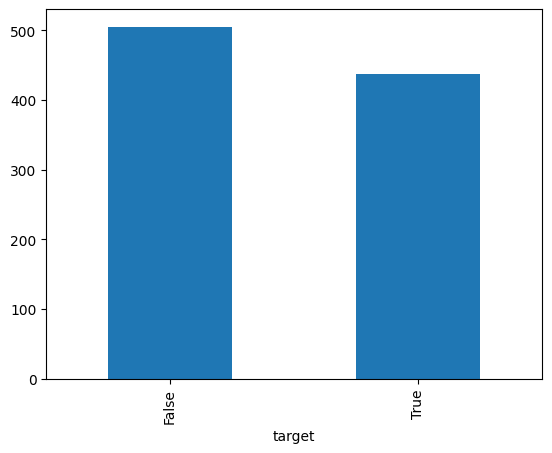

In [30]:
ax = spx_daily["target"].value_counts().plot(kind="bar")